# 7 — Kernel-Parameter Sweep at Fixed Spacing (CAN-only)

Fixes the network `spacing` and runs a **single Optuna study over the three knobs that set
bump health and tracking** — `sigma` (inhibitory kernel width), `alpha` (kernel amplitude),
and `offset_magnitude` (velocity gain) — with `b` held fixed. Scoring is CAN-only through the
torch **FFT** backend (`simulate`), so no dense connectivity matrix is ever built.

**Why these axes.** The recurrent kernel is `k(d) = α·exp(−d²/2σ²) − α` — purely inhibitory
(Burak & Fiete-style), with the excitation supplied by the uniform drive `b`. `sigma` sets the
bump's spatial scale; `alpha` sets the inhibition gain. At fine spacing the recurrent term is
inflated ∝ n³ while `b` is fixed, so **sweeping `alpha` is what re-balances excitation/inhibition
back into the single-bump regime** — it does the job you'd otherwise do by hand-rescaling `b`.
`offset_magnitude` sets how fast the bump tracks velocity.

**Order of operations.** (0) verify `build_connectivity=False` actually skips the dense build, at
a *safe small n*; (2) prove construction at the target spacing is cheap on this machine; (3) sweep;
(5) inspect + visualise the winning bump; (6) validate robustness; (7) recording guidance for the
long runs. `b` is fixed on purpose (see notes).

Requires: `pip install optuna plotly matplotlib pandas scipy`.

In [14]:
import os, sys, gc, inspect, math, time, dataclasses
import numpy as np
from scipy import ndimage
import optuna

# adjust to your layout (mirrors notebook 4_pipeline_integration)
sys.path.insert(0, os.path.abspath("../.."))

from config import RunConfig, NetworkConfig
from experiments.arena_2d import Arena2DExperiment, Arena2DConfig
from experiments.base import BaseExperiment
from network.QAN3D import Torus3DQAN
from network.torch_backend import TorchBackend

# ---- fixed design ---------------------------------------------------------
SPACING = 0.1          # FIXED. Gated by assert_flag_effective() below.
                       #   If that raises: fix CAN3D's flag, or set SPACING = 0.2.
B       = 1.6          # feedforward drive, held fixed (your QAN default)
T       = 600          # short sim per trial; [200:] leaves ~400 post-transient steps
SEED    = 0
N_TRIALS = 50          # 3 axes -> TPE needs more samples than the 2-axis sweep

# swept axes (kernel shape + velocity gain); b is NOT swept
SIGMA_RANGE  = (0.8, 1.7)    # inhibitory kernel width (radians)
ALPHA_RANGE  = (0.3, 1.5)    # kernel amplitude; brackets bump-death around the 0.8 default
OFFSET_RANGE = (0.15, 0.50)  # +/- coordinate shift -> velocity gain

PENALTY      = 1e3     # >> any valid error; returned for dead/smeared/split or failed trials
COVERAGE_MAX = 0.20    # gate: a single healthy bump covers <~20% of the torus above half-max
print("setup ok | SPACING =", SPACING, "| axes: sigma, alpha, offset_magnitude | b fixed =", B)

setup ok | SPACING = 0.1 | axes: sigma, alpha, offset_magnitude | b fixed = 1.6


## 0 — Verify the flag before anything expensive

`build_connectivity=False` only helps if `CAN3D.__post_init__` actually reads it. We test that at
spacing **0.5 (n=13)**, where the dense matrix is ~38 MB per CAN and *cannot* OOM — and since the
branch in `__post_init__` is n-independent, the result holds at n=63. If `build_connectivity=False`
still leaves a `connectivity_matrix`, the flag is inert and this cell **raises**, because at 0.1
each trial would otherwise try to allocate ~1.5 TB across the six CANs.

In [15]:
def assert_flag_effective():
    """
    Confirm build_connectivity=False actually skips the dense connectivity_matrix.
    Tested at a SMALL spacing (n=13, ~38 MB/CAN) so this probe can never OOM. The branch in
    __post_init__ is n-independent, so the result generalises to SPACING=0.1.
    """
    sp = 0.5  # n = ceil(2*pi/0.5) = 13
    probe = dict(alpha=0.8, sigma=1.5, offset_magnitude=0.25, b=B)

    q_off = Torus3DQAN(spacing=sp, build_connectivity=False, **probe)
    off = any(hasattr(c, "connectivity_matrix") for c in q_off.cans)
    del q_off; gc.collect()

    q_on = Torus3DQAN(spacing=sp, build_connectivity=True, **probe)
    on = any(hasattr(c, "connectivity_matrix") for c in q_on.cans)
    del q_on; gc.collect()

    print(f"connectivity_matrix present  ->  build_connectivity=True: {on} | =False: {off}")
    if off:
        raise RuntimeError(
            "build_connectivity=False does NOT skip the dense build (matrix still present) -- "
            "the flag is inert at construction. At SPACING=0.1 each trial would allocate ~1.5 TB "
            "across the 6 CANs. Fix CAN3D.__post_init__ to honour the flag, or set SPACING=0.2."
        )
    if not on:
        print("  WARNING: True did not build it either -- probe may be on the wrong attribute or "
              "the build is deferred; verify by watching RAM during a real 0.1 construction.")
    print("flag OK: False skips the matrix, True builds it -- safe to construct at fine spacing.")

assert_flag_effective()

connectivity_matrix present  ->  build_connectivity=True: True | =False: False
flag OK: False skips the matrix, True builds it -- safe to construct at fine spacing.


## 1 — Bump-health metric

A trial's MADE error is only meaningful if a single coherent bump exists. `bump_metrics` rolls the
global peak to centre, counts blobs above half-max (`n_peaks`), and measures `coverage` = fraction
of voxels above half-max. For a fixed-radian-width Gaussian bump, coverage is ~scale-invariant (the
n's cancel), so one fixed threshold works across spacings: a healthy single bump covers well under
20% of the torus above half-max, while a dead/uniform field covers ~all of it. Hard gate:
`n_peaks == 1 and coverage <= COVERAGE_MAX`.

In [16]:
def bump_metrics(S_tot, n=None):
    """
    Diagnostics on the relu'd bump activity. S_tot: 1-D array of N = n**3 values
    (one CAN's worth, i.e. backend.S.mean(dim=0)).
      n_peaks  : blobs above half-max after rolling the global peak to centre (1=healthy, 0=dead).
      coverage : fraction of voxels above half-max (~scale-invariant; large => smeared/dead).
      status   : 'ok' | 'dead' | 'split' | 'smeared'.
    Raises if S_tot is not a perfect cube of n (never trust ceil(2*pi/spacing) for the shape).
    """
    r = np.maximum(np.asarray(S_tot, dtype=float).ravel(), 0.0)
    N = r.size
    if n is None:
        n = int(round(N ** (1.0 / 3.0)))
    if n ** 3 != N:
        raise ValueError(f"S_tot has {N} entries, not a cube of n={n} (n^3={n**3}).")
    if r.sum() <= 0.0:
        return dict(n_peaks=0, coverage=0.0, status="dead")

    cube = r.reshape(n, n, n)
    thr  = 0.5 * cube.max()
    coverage = float((cube >= thr).mean())

    pk = np.unravel_index(cube.argmax(), cube.shape)
    shifted = np.roll(cube, [s // 2 - p for s, p in zip(cube.shape, pk)], axis=(0, 1, 2))
    _, n_blobs = ndimage.label(shifted >= thr)
    n_peaks = int(n_blobs)

    status = ("dead" if n_peaks == 0 else
              "split" if n_peaks > 1 else
              "smeared" if coverage > COVERAGE_MAX else "ok")
    return dict(n_peaks=n_peaks, coverage=coverage, status=status)

## 2 — Trajectory + target-spacing construction proof

`torus_gt` depends only on the manifold metric and `grid_spacing`, **not** the network `spacing`,
so we generate it once with a coarse, cheap network. Then we actually construct the QAN **at the
target spacing** to confirm — on this machine — that it's megabytes and matrix-free. The reference
bump at default-ish params is printed for information only; at fine spacing it may not be a single
bump, which is exactly why we sweep `alpha`.

In [23]:
# --- trajectory once, via a coarse (cheap) network so nothing dense is built to get the walk ---
net_fields = {f.name for f in dataclasses.fields(NetworkConfig)}
traj_net_kw = dict(spacing=0.5)
if "build_connectivity" in net_fields:
    traj_net_kw["build_connectivity"] = False
print(traj_net_kw)
base = Arena2DExperiment(
    RunConfig(network=NetworkConfig(**traj_net_kw), experiment=Arena2DConfig(n_steps=T, seed=SEED)),
    record=False,
)
world_pos, v_body_seq, torus_gt = base.generate_trajectory()
print("torus_gt:", torus_gt.shape, "| world_pos:", world_pos.shape)
del base; gc.collect()

# --- prove construction at the TARGET spacing is cheap (flag really works at this n) ---
t0 = time.time()
ref_qan = Torus3DQAN(spacing=SPACING, alpha=0.8, sigma=1.5,
                     offset_magnitude=0.25, b=B, build_connectivity=False)
build_s = time.time() - t0
n_axis = int(round(ref_qan.cans[0].S.shape[0] ** (1.0 / 3.0)))
has_dense = any(hasattr(c, "connectivity_matrix") for c in ref_qan.cans)
print(f"built Torus3DQAN(spacing={SPACING}) in {build_s:.2f}s | n/axis={n_axis} "
      f"| neurons/CAN={n_axis**3:,} | dense matrix present: {has_dense}")
assert not has_dense, "dense matrix present at SPACING despite build_connectivity=False -- stop."

# --- reference bump (REPORT only; the gate uses the fixed geometric COVERAGE_MAX) ---
ref_backend = TorchBackend(qan=ref_qan)
_ = ref_backend.simulate(torus_gt)
ref_S = ref_backend.S.mean(dim=0).squeeze().detach().cpu().numpy()
print("reference bump (default-ish params at this spacing):", bump_metrics(ref_S, n_axis))
print("note: at fine spacing the default params may NOT be one bump -- that is what the alpha "
      f"sweep is for. Gate uses COVERAGE_MAX={COVERAGE_MAX} (geometry-based), not this reference.")
del ref_qan, ref_backend; gc.collect()


{'spacing': 0.5}
torus_gt: (600, 3) | world_pos: (600, 3)
built Torus3DQAN(spacing=0.1) in 0.16s | n/axis=63 | neurons/CAN=250,047 | dense matrix present: False
reference bump (default-ish params at this spacing): {'n_peaks': 1, 'coverage': 0.00032393909944930353, 'status': 'ok'}
note: at fine spacing the default params may NOT be one bump -- that is what the alpha sweep is for. Gate uses COVERAGE_MAX=0.2 (geometry-based), not this reference.


34

## 3 — Objective and study

Each trial builds a fresh QAN with `build_connectivity=False`, runs `simulate`, gates on bump
health, and returns the post-transient MADE error — or `PENALTY` if the bump is dead/smeared/split
or construction fails. `made_error` uses the harness metric where available and a transparent
wrapped-angular fallback otherwise (only one path is used per run, so the objective is internally
consistent).

In [18]:
def made_error(decoded, gt, world_pos, burn=200):
    """Post-transient path-integration error. Primary path matches the harness
    (BaseExperiment._made_metric, normalised by cumulative distance); fallback is a transparent
    mean wrapped-angular error per step."""
    try:
        e = np.asarray(BaseExperiment._made_metric(decoded, gt, world_pos=world_pos), dtype=float)
        return float(e[burn:].mean()) if e.ndim >= 1 and e.shape[0] > burn else float(e.mean())
    except Exception:
        d = (np.asarray(decoded) - np.asarray(gt) + np.pi) % (2 * np.pi) - np.pi
        return float(np.linalg.norm(d, axis=-1)[burn:].mean())


def objective(trial):
    sigma  = trial.suggest_float("sigma",            *SIGMA_RANGE)
    alpha  = trial.suggest_float("alpha",            *ALPHA_RANGE)
    offset = trial.suggest_float("offset_magnitude", *OFFSET_RANGE)
    qan = backend = None
    try:
        qan = Torus3DQAN(spacing=SPACING, alpha=alpha, sigma=sigma,
                         offset_magnitude=offset, b=B, build_connectivity=False)
        backend = TorchBackend(qan=qan)
        decoded = backend.simulate(torus_gt)

        S_tot  = backend.S.mean(dim=0).squeeze().detach().cpu().numpy()
        n_state = int(round(S_tot.size ** (1.0 / 3.0)))
        bm = bump_metrics(S_tot, n_state)
        for k, v in bm.items():
            trial.set_user_attr(k, v)

        healthy = (bm["n_peaks"] == 1 and bm["coverage"] <= COVERAGE_MAX)
        trial.set_user_attr("healthy", bool(healthy))
        if not healthy:
            return PENALTY
        err = made_error(decoded, torus_gt, world_pos)
        return err if np.isfinite(err) else PENALTY
    except (TypeError, ValueError, RuntimeError, MemoryError) as e:
        print(f"  FAIL sigma={sigma:.3f} alpha={alpha:.3f} offset={offset:.3f}: {type(e).__name__}: {e}")
        return PENALTY
    finally:
        del qan, backend
        gc.collect()

## 4 — Run

In [19]:
import pandas as pd

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS)

n_ok = sum(t.user_attrs.get("healthy", False) for t in study.trials)
if n_ok == 0:
    print(f"no healthy single-bump trial in {N_TRIALS} -- every (sigma,alpha,offset) was dead/"
          "smeared/split. Widen ALPHA_RANGE or raise b; best value is the penalty floor.")
else:
    print(f"best {study.best_params} -> {study.best_value:.5f}   ({n_ok}/{N_TRIALS} healthy)")

rows = [dict(number=t.number, value=t.value,
             sigma=t.params.get("sigma"), alpha=t.params.get("alpha"),
             offset_magnitude=t.params.get("offset_magnitude"),
             healthy=t.user_attrs.get("healthy"), status=t.user_attrs.get("status"),
             coverage=t.user_attrs.get("coverage"), n_peaks=t.user_attrs.get("n_peaks"))
        for t in study.trials]
summary = pd.DataFrame(rows).sort_values("value").reset_index(drop=True)
summary.head(15)

[I 2026-05-30 22:55:13,485] A new study created in memory with name: no-name-5e1e27bf-f55e-4448-9148-d6119489d9c3
[I 2026-05-30 22:55:24,159] Trial 0 finished with value: 1000.0 and parameters: {'sigma': 1.2939321535345922, 'alpha': 1.1582272396469033, 'offset_magnitude': 0.36096718162507535}. Best is trial 0 with value: 1000.0.
[I 2026-05-30 22:55:35,924] Trial 1 finished with value: 1000.0 and parameters: {'sigma': 1.2903948646972072, 'alpha': 0.8083857592066857, 'offset_magnitude': 0.3760629395733296}. Best is trial 0 with value: 1000.0.
[I 2026-05-30 22:55:45,582] Trial 2 finished with value: 1000.0 and parameters: {'sigma': 1.1938284901364233, 'alpha': 1.3701276009384957, 'offset_magnitude': 0.48728196617536024}. Best is trial 0 with value: 1000.0.
[I 2026-05-30 22:55:54,807] Trial 3 finished with value: 1000.0 and parameters: {'sigma': 1.1450973669432, 'alpha': 1.2500700456991976, 'offset_magnitude': 0.33511322191351656}. Best is trial 0 with value: 1000.0.
[I 2026-05-30 22:56:03

best {'sigma': 1.3477713281681538, 'alpha': 0.4986873874893713, 'offset_magnitude': 0.3495788593354629} -> 0.87074   (25/50 healthy)


,number,value,sigma,alpha,offset_magnitude,healthy,status,coverage,n_peaks
0,43,0.870735,1.347771,0.498687,0.349579,True,ok,0.000928,1
1,24,0.879268,1.376004,0.464454,0.346867,True,ok,0.000980,1
2,27,0.879371,1.335650,0.523226,0.349119,True,ok,0.000848,1
3,25,0.887098,1.339803,0.496779,0.346546,True,ok,0.000916,1
4,36,0.896242,1.295772,0.405421,0.339228,True,ok,0.001036,1
5,38,0.928677,1.302304,0.683093,0.347782,True,ok,0.000620,1
6,31,0.935285,1.339958,0.425609,0.336016,True,ok,0.001048,1
7,35,0.952454,1.219792,0.466570,0.330924,True,ok,0.000836,1
8,41,0.960942,1.302094,0.668830,0.341618,True,ok,0.000668,1
9,22,1.081517,1.335194,0.317318,0.317038,True,ok,0.000812,1


## 5 — Inspect: importances, slices, and the winning bump

Slice plots show each axis against the objective; the three-panel image is the winning bump sliced
through its peak — confirm by eye that it's one clean hump, not a ring or a smear.

In [20]:
import optuna.visualization as vis

if any(t.user_attrs.get("healthy", False) for t in study.trials):
    vis.plot_param_importances(study).show()
    vis.plot_slice(study, params=["sigma", "alpha", "offset_magnitude"]).show()
else:
    print("no healthy trial to visualise.")

ImportError: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.

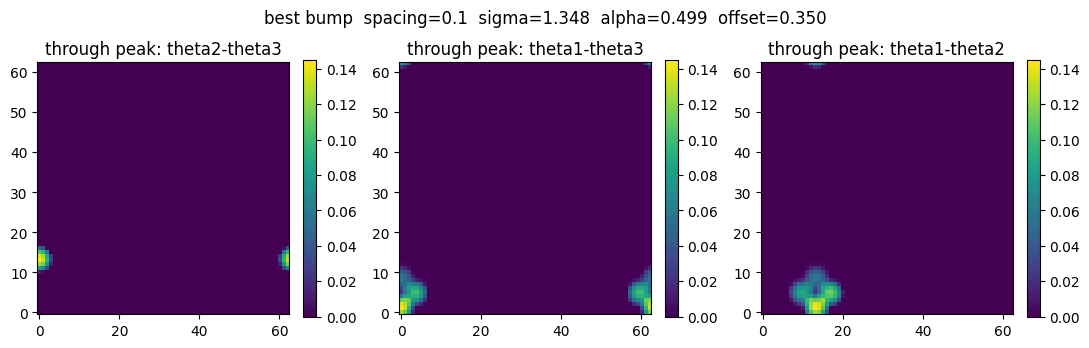

In [21]:
import matplotlib.pyplot as plt

if any(t.user_attrs.get("healthy", False) for t in study.trials):
    bp = study.best_params
    qan = Torus3DQAN(spacing=SPACING, alpha=bp["alpha"], sigma=bp["sigma"],
                     offset_magnitude=bp["offset_magnitude"], b=B, build_connectivity=False)
    backend = TorchBackend(qan=qan)
    _ = backend.simulate(torus_gt)
    S_tot = backend.S.mean(dim=0).squeeze().detach().cpu().numpy()
    n_axis = int(round(S_tot.size ** (1.0 / 3.0)))
    cube = np.maximum(S_tot, 0.0).reshape(n_axis, n_axis, n_axis)
    pk = np.unravel_index(cube.argmax(), cube.shape)

    fig, ax = plt.subplots(1, 3, figsize=(11, 3.4))
    panels = [(cube[pk[0]], "theta2-theta3"), (cube[:, pk[1]], "theta1-theta3"),
              (cube[:, :, pk[2]], "theta1-theta2")]
    for a, (sl, ttl) in zip(ax, panels):
        im = a.imshow(sl, origin="lower"); a.set_title(f"through peak: {ttl}")
        plt.colorbar(im, ax=a, fraction=0.046)
    fig.suptitle(f"best bump  spacing={SPACING}  sigma={bp['sigma']:.3f}  "
                 f"alpha={bp['alpha']:.3f}  offset={bp['offset_magnitude']:.3f}")
    fig.tight_layout(); plt.show()
    del qan, backend; gc.collect()
else:
    print("no healthy winner to plot.")

## 6 — Validate the winner

First a reliable check: re-run the winner on **fresh trajectories** through the torch backend
(works at n=63). Then a **best-effort full-pipeline** run with the filter in the loop — which only
succeeds if `PathIntegrator` drives the torch backend; the dense NumPy CAN path is incompatible with
`build_connectivity=False` at fine spacing, and the cell says so if it fails.

In [22]:
if not any(t.user_attrs.get("healthy", False) for t in study.trials):
    print("no healthy winner to validate.")
else:
    bp = study.best_params
    print(f"winner: spacing={SPACING} sigma={bp['sigma']:.3f} alpha={bp['alpha']:.3f} "
          f"offset={bp['offset_magnitude']:.3f} | CAN-only err={study.best_value:.5f}\n")
    nf = {f.name for f in dataclasses.fields(NetworkConfig)}

    # (a) CAN-only robustness across fresh trajectories (reliable: torch FFT backend, runs at n=63)
    print("CAN-only robustness across fresh trajectories:")
    for seed in range(1, 4):
        tn = dict(spacing=0.5)
        if "build_connectivity" in nf: tn["build_connectivity"] = False
        b2 = Arena2DExperiment(RunConfig(network=NetworkConfig(**tn),
                               experiment=Arena2DConfig(n_steps=T, seed=seed)), record=False)
        _, _, gt2 = b2.generate_trajectory(); del b2; gc.collect()
        qan = Torus3DQAN(spacing=SPACING, alpha=bp["alpha"], sigma=bp["sigma"],
                         offset_magnitude=bp["offset_magnitude"], b=B, build_connectivity=False)
        backend = TorchBackend(qan=qan)
        dec = backend.simulate(gt2)
        S = backend.S.mean(dim=0).squeeze().detach().cpu().numpy()
        na = int(round(S.size ** (1.0 / 3.0)))
        print(f"  seed {seed}: err={made_error(dec, gt2, world_pos):.5f}  "
              f"bump={bump_metrics(S, na)['status']}")
        del qan, backend; gc.collect()

    # (b) best-effort FULL pipeline (filter in the loop) at the same spacing
    print("\nfull-pipeline (filter in loop), best-effort:")
    net_kw = dict(spacing=SPACING, sigma=bp["sigma"], offset_magnitude=bp["offset_magnitude"])
    if "b" in nf:            net_kw["b"] = B
    if "kernel_alpha" in nf: net_kw["kernel_alpha"] = bp["alpha"]
    elif "alpha" in nf:      net_kw["alpha"] = bp["alpha"]
    if "build_connectivity" in nf: net_kw["build_connectivity"] = False
    try:
        res = Arena2DExperiment(RunConfig(network=NetworkConfig(**net_kw),
                                experiment=Arena2DConfig(n_steps=2000, seed=0)),
                                record=False).run_experiment(g=np.array([0., 0., -9.81]))
        print(f"  mean_norm_error = {res.mean_norm_error:.4f}")
    except Exception as e:
        print(f"  could NOT run full pipeline at spacing={SPACING}: {type(e).__name__}: {e}")
        print("  -> likely the pipeline uses the dense NumPy CAN (step_stateless), which needs the "
              "matrix that build_connectivity=False skips. Validate at a coarser spacing, or wire "
              "PathIntegrator to the torch backend, to test the filter loop at this resolution.")

winner: spacing=0.1 sigma=1.348 alpha=0.499 offset=0.350 | CAN-only err=0.87074

CAN-only robustness across fresh trajectories:
  seed 1: err=0.55004  bump=split
  seed 2: err=1.00118  bump=ok
  seed 3: err=0.58088  bump=ok

full-pipeline (filter in loop), best-effort:


KeyboardInterrupt: 

## 7 — Recording for long analysis runs

The sweep is memory-light (short T, no full-state buffer). The 40 GB figure is for **production
runs** that record `S_tot` every step over T~40k for rate maps. Cut it with a temporal **stride**
(keep the full field, fewer frames) and/or a **neuron subset**. The buffer is allocated on-device,
so this is what keeps it off a rented GPU's memory.

In [ ]:
def allocate_record_buffer(backend, T, stride=1, neuron_idx=None):
    """On-device buffer for S_tot, optionally strided in time and/or restricted to a neuron subset."""
    n_frames = (T + stride - 1) // stride
    width = backend.S.shape[1] if neuron_idx is None else len(neuron_idx)
    return torch.empty((n_frames, width), dtype=backend.torch_dtype, device=backend.device), n_frames

def maybe_record(backend, buf, t, stride=1, neuron_idx=None):
    """Call once per step; writes S_tot (or its subset) into row t//stride when t hits the stride."""
    if t % stride:
        return
    row = backend.S.mean(dim=0).squeeze()
    buf[t // stride] = row if neuron_idx is None else row[neuron_idx]

import torch
N63 = 63 ** 3
print("recording-buffer memory for long runs (device buffer = frames x width x 4 B):")
for (T_, stride, sub) in [(40000, 1, None), (40000, 10, None), (40000, 1, 5000), (40000, 10, 5000)]:
    width = N63 if sub is None else sub
    frames = (T_ + stride - 1) // stride
    gb = frames * width * 4 / 1e9
    sub_label = "all" if sub is None else str(sub)
    print(f"  T={T_} stride={stride:>2} neurons={sub_label:>5} -> "
          f"{frames:>5} x {width:>7,} x4B = {gb:6.2f} GB")

## 8 — Notes

- **No healthy trial?** The `alpha` range didn't reach the stable regime — widen it (or raise `b`)
  and rerun; the printout tells you which.
- **`b` is fixed on purpose.** If you'd rather co-tune it, add `b = trial.suggest_float("b", ...)`
  and pass it to the constructor — but expect an `alpha`–`b` ridge of near-equivalent solutions,
  since both move the operating point of `relu(α·W⊛S + b)`.
- **Trial time is CPU-FFT-bound.** `_apply_W_fft` runs the FFT on CPU regardless of device, so time
  scales with `T` and `n³`; drop `N_TRIALS` or `T` for a quick first pass.
- **Decode-granularity floor.** The CAN-only error has a floor that depends on spacing; since
  spacing is fixed here, comparisons across trials are clean.